# 02. Vanilla LSTM / TCN Physics Blindness

Vanilla LSTM and TCN backbones are powerful sequence regressors, but their default objective is statistical, not physical. With a plain MSE loss, the model is rewarded for reducing average squared error. It is not punished structurally for a local violation such as `SOC_hat[t+1] > SOC_hat[t]` while current indicates discharge.

That makes the baseline unsafe for Battery Management Systems. A low MSE model can still claim the battery regained SOC during active discharge if that local increase improves the average fit elsewhere. PVR exposes this failure mode: it counts monotonicity violations under discharge, not just numeric distance from the label.

This notebook loads the historical ledgers that survived the project archaeology. Important honesty note: the saved logs report PVR at the evaluated test-split scope, not a separately stored per-temperature `-20 C` PVR. Scenario A is the cold/generalization OOD split that includes `-20 C`; Scenario B includes `-20 C` in chronological test windows. The chart below therefore uses audited cold-scope test PVR and does not fabricate unavailable per-temperature PVR.


In [1]:
from pathlib import Path
import sys
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except Exception:
    display = print

def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / 'src').exists() and (candidate / 'outputs').exists():
            return candidate
    raise FileNotFoundError('Could not locate project root containing src/ and outputs/.')

ROOT = find_project_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

FIG_DIR = ROOT / 'outputs' / 'figures' / 'ablation_studies'
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.titleweight': 'bold',
    'axes.labelsize': 10,
    'legend.fontsize': 8.5,
    'legend.frameon': False,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.15,
    'grid.linestyle': '-',
})

print(f'Project root: {ROOT}')
print(f'Figure output: {FIG_DIR}')


Project root: d:\Tugas kuliah\SEM 6\PROYEK DATA MINING\PENELITIAN\Penelitian_SOC
Figure output: d:\Tugas kuliah\SEM 6\PROYEK DATA MINING\PENELITIAN\Penelitian_SOC\outputs\figures\ablation_studies


## Load historical PVR ledgers

The table combines three ledgers: final Sprint 48 LSTM evaluation, legacy Sprint 44 TCN/LSTM baseline results, and Sprint 52 Hard-Coulomb TCN redemption results. The goal is not to claim equal training protocols across every historical sprint; the goal is to show the safety pattern: unconstrained baselines have nonzero PVR, while Hard-Coulomb architectures have exactly zero violations.


In [2]:
sprint48_path = ROOT / 'outputs' / 'v7_final' / 'sprint48_evaluation_results.json'
sprint44_path = ROOT / 'logs' / 'sprint44_results_v3.json'
sprint52_path = ROOT / 'outputs' / 'v8_tcn_redemption' / 'sprint52' / 'sprint52_tcn_redemption_results.json'

for path in [sprint48_path, sprint44_path, sprint52_path]:
    if not path.exists():
        raise FileNotFoundError(path)

sprint48 = json.loads(sprint48_path.read_text(encoding='utf-8'))
sprint44 = json.loads(sprint44_path.read_text(encoding='utf-8'))
sprint52 = json.loads(sprint52_path.read_text(encoding='utf-8'))

def sprint48_row(model_kind, scenario, label, backbone, topology):
    match = [r for r in sprint48 if r['model_kind'] == model_kind and r['scenario'] == scenario]
    if len(match) != 1:
        raise ValueError(f'Expected one Sprint48 row for {model_kind}/{scenario}, found {len(match)}')
    r = match[0]
    m = r['metrics']
    return {
        'Model': label,
        'Backbone': backbone,
        'Topology': topology,
        'Scenario': scenario.replace('scenario_', 'Scenario '),
        'Scope note': 'Scenario A OOD test includes -20 C' if scenario == 'scenario_A' else 'Scenario B chronological test includes -20 C',
        'PVR (%)': float(m['pvr_pct']),
        'Violations': int(m['pvr_violations']),
        'Discharge steps': int(m['pvr_discharge_steps']),
        'RMSE full (%)': float(m['rmse_full_pct']),
        'Source': str(sprint48_path.relative_to(ROOT)),
    }

def sprint44_row(model, scenario, label, backbone, topology):
    match = [r for r in sprint44['results'] if r['model'] == model and r['scenario'] == scenario]
    if len(match) != 1:
        raise ValueError(f'Expected one Sprint44 row for {model}/{scenario}, found {len(match)}')
    r = match[0]
    return {
        'Model': label,
        'Backbone': backbone,
        'Topology': topology,
        'Scenario': scenario.replace('_', ' '),
        'Scope note': 'Legacy test scope; Scenario B includes -20 C chronological windows',
        'PVR (%)': float(r['pvr']),
        'Violations': int(r['n_violations']),
        'Discharge steps': int(r['n_discharge']),
        'RMSE full (%)': float(r['rmse_pct']),
        'Source': str(sprint44_path.relative_to(ROOT)),
    }

def sprint52_row(scenario, label, backbone, topology):
    match = [r for r in sprint52['results'] if r.get('model') == 'HardCoulombTCN' and r.get('scenario') == scenario]
    if len(match) != 1:
        raise ValueError(f'Expected one Sprint52 HardCoulombTCN row for {scenario}, found {len(match)}')
    r = match[0]
    m = r['metrics']
    return {
        'Model': label,
        'Backbone': backbone,
        'Topology': topology,
        'Scenario': scenario.replace('scenario_', 'Scenario '),
        'Scope note': 'Scenario B chronological test includes -20 C' if scenario == 'scenario_B' else 'Scenario A OOD test includes -20 C',
        'PVR (%)': float(m['pvr_pct']),
        'Violations': int(m['pvr_violations']),
        'Discharge steps': int(m['pvr_discharge_steps']),
        'RMSE full (%)': float(m['rmse_full_pct']),
        'Source': str(sprint52_path.relative_to(ROOT)),
    }

pvr_rows = [
    sprint48_row('vanilla_lstm', 'scenario_A', 'Vanilla LSTM', 'LSTM', 'MSE only'),
    sprint44_row('TCN', 'Scenario_B', 'Vanilla TCN', 'TCN', 'MSE only'),
    sprint48_row('hard_coulomb_lstm', 'scenario_A', 'Hard-Coulomb LSTM', 'LSTM', 'Smooth Hard-Coulomb'),
    sprint52_row('scenario_B', 'Hard-Coulomb TCN', 'TCN', 'Smooth Hard-Coulomb'),
]
pvr_df = pd.DataFrame(pvr_rows)
display(pvr_df.round({'PVR (%)': 4, 'RMSE full (%)': 3}))

assert (pvr_df[pvr_df['Topology'] == 'Smooth Hard-Coulomb']['PVR (%)'] == 0.0).all(), 'Hard-Coulomb PVR is not zero.'
assert (pvr_df[pvr_df['Topology'] == 'MSE only']['PVR (%)'] > 0.0).all(), 'Vanilla baselines should have nonzero PVR.'


,Model,Backbone,Topology,Scenario,Scope note,PVR (%),Violations,Discharge steps,RMSE full (%),Source
0,Vanilla LSTM,LSTM,MSE only,Scenario A,Scenario A OOD test includes -20 C,49.9694,646223,1293237,13.371,outputs\v7_final\sprint48_evaluation_results.json
1,Vanilla TCN,TCN,MSE only,Scenario B,Legacy test scope; Scenario B includes -20 C c...,50.5464,362304,716775,5.483,logs\sprint44_results_v3.json
2,Hard-Coulomb LSTM,LSTM,Smooth Hard-Coulomb,Scenario A,Scenario A OOD test includes -20 C,0.0000,0,1293237,12.711,outputs\v7_final\sprint48_evaluation_results.json
3,Hard-Coulomb TCN,TCN,Smooth Hard-Coulomb,Scenario B,Scenario B chronological test includes -20 C,0.0000,0,359309,8.582,outputs\v8_tcn_redemption\sprint52\sprint52_tc...


## PVR bar chart

The chart highlights the safety distinction. Vanilla sequence models are expressive enough to fit average SOC, but they are not constrained to respect discharge monotonicity. Hard-Coulomb models route every sequence increment through current sign and a Coulomb envelope, so PVR is zero by topology.


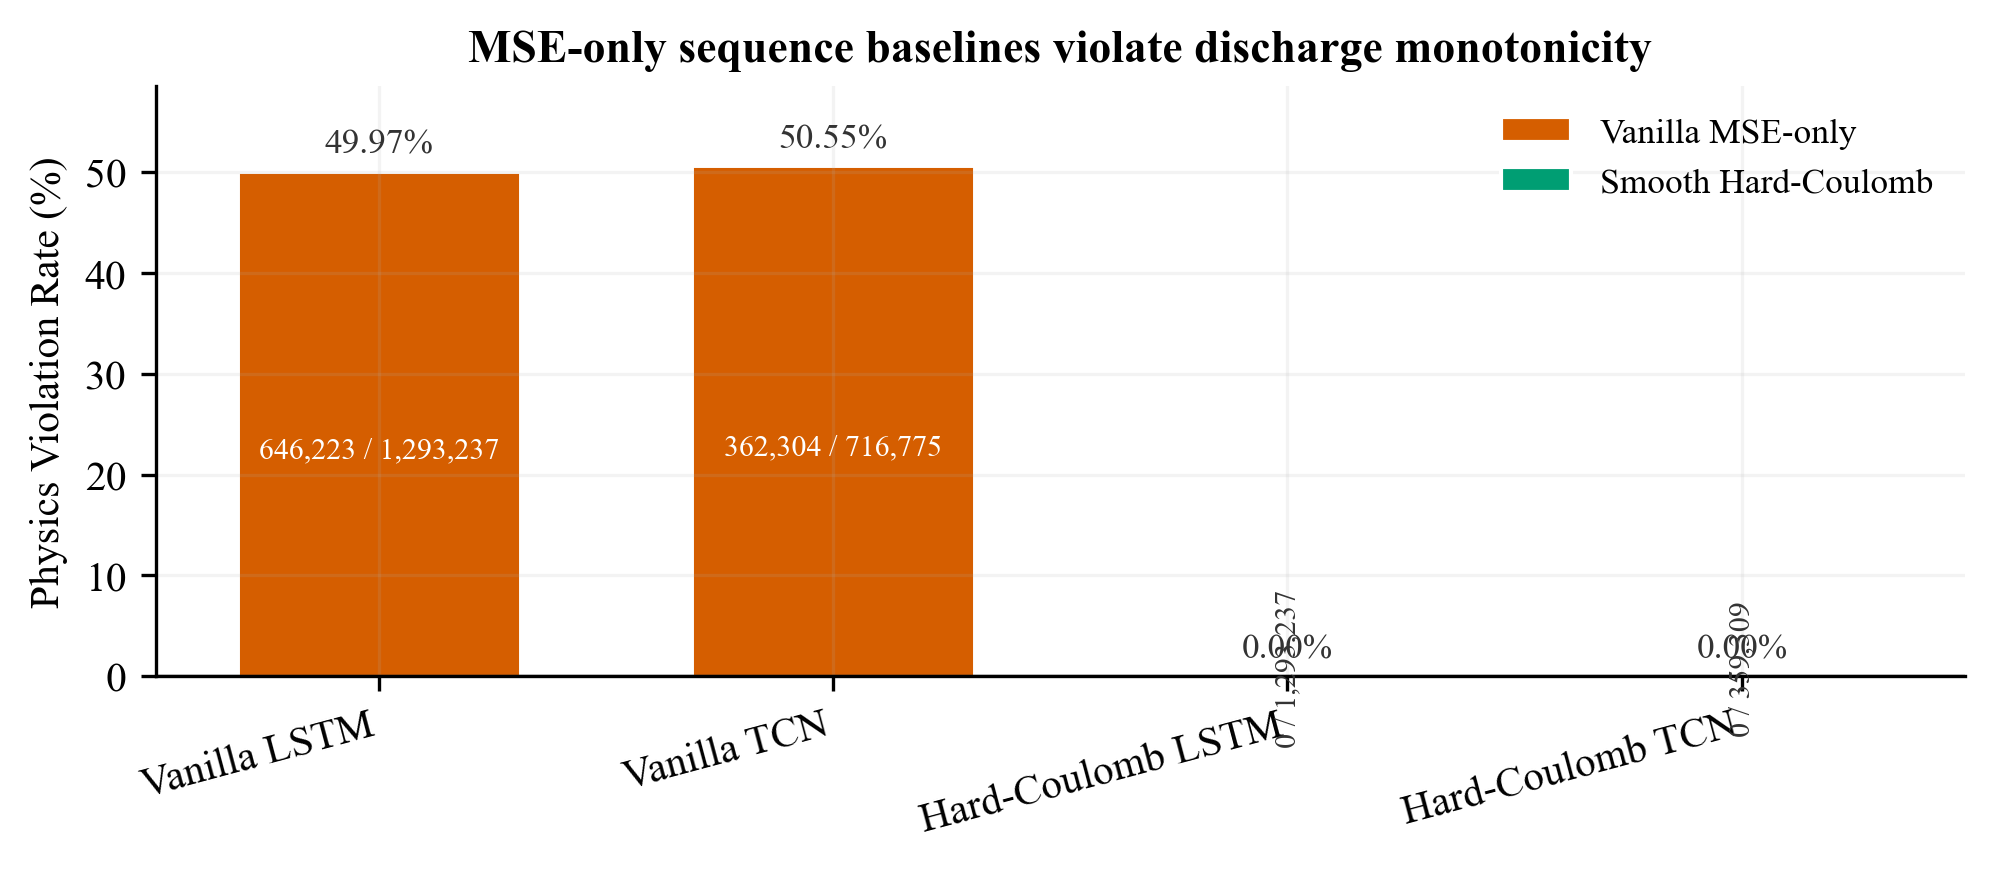

Saved: d:\Tugas kuliah\SEM 6\PROYEK DATA MINING\PENELITIAN\Penelitian_SOC\outputs\figures\ablation_studies\fig_02_vanilla_physics_blindness_pvr.pdf
Saved: d:\Tugas kuliah\SEM 6\PROYEK DATA MINING\PENELITIAN\Penelitian_SOC\outputs\figures\ablation_studies\fig_02_vanilla_physics_blindness_pvr.png


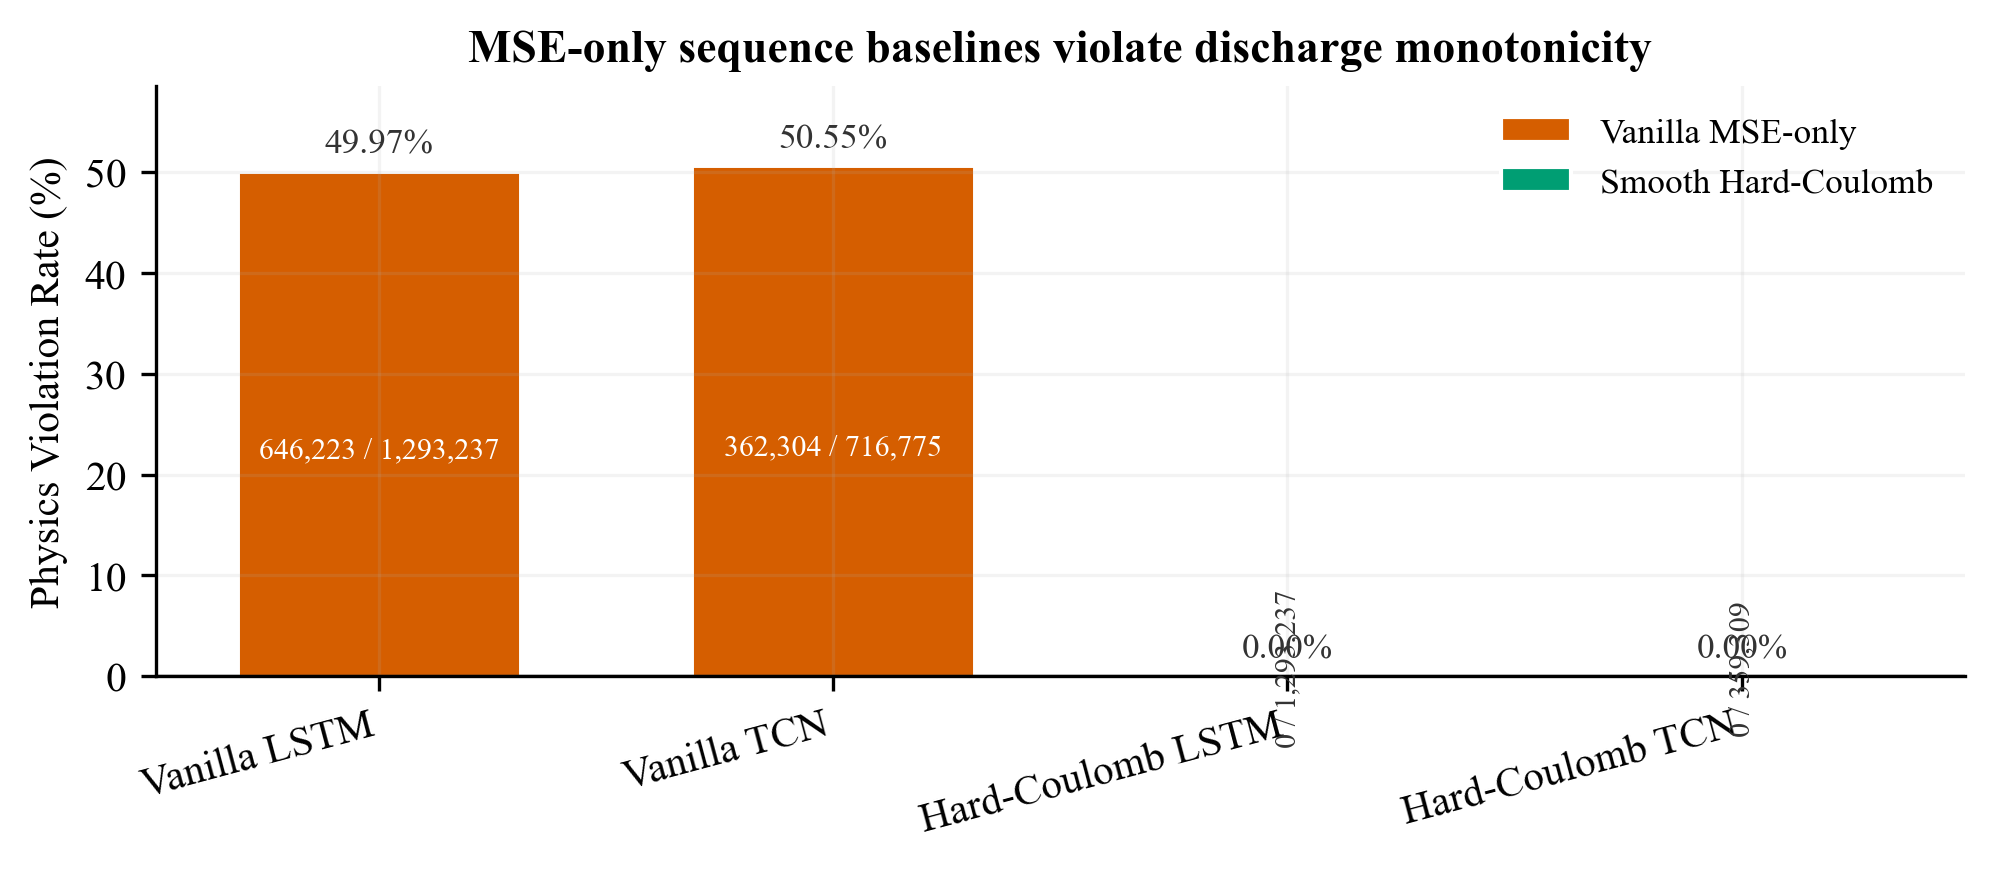

In [3]:
fig, ax = plt.subplots(figsize=(6.75, 3.0))
colors = ['#D55E00' if topo == 'MSE only' else '#009E73' for topo in pvr_df['Topology']]
x = np.arange(len(pvr_df))
bars = ax.bar(x, pvr_df['PVR (%)'], color=colors, edgecolor='white', linewidth=0.7, width=0.62)

for bar, value, viol, steps in zip(bars, pvr_df['PVR (%)'], pvr_df['Violations'], pvr_df['Discharge steps']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1.2,
        f'{value:.2f}%',
        ha='center',
        va='bottom',
        fontsize=8.5,
        color='#333333',
    )
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        max(0.8, bar.get_height() * 0.45),
        f'{viol:,} / {steps:,}',
        ha='center',
        va='center',
        fontsize=7.2,
        rotation=90 if value < 5 else 0,
        color='white' if value > 8 else '#333333',
    )

ax.set_xticks(x)
ax.set_xticklabels(pvr_df['Model'], rotation=15, ha='right')
ax.set_ylabel('Physics Violation Rate (%)')
ax.set_ylim(0, max(55.0, pvr_df['PVR (%)'].max() + 8.0))
ax.set_title('MSE-only sequence baselines violate discharge monotonicity')
ax.axhline(0, color='#333333', linewidth=0.8)

from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor='#D55E00', edgecolor='white', label='Vanilla MSE-only'),
    Patch(facecolor='#009E73', edgecolor='white', label='Smooth Hard-Coulomb'),
]
ax.legend(handles=legend_handles, loc='upper right')
fig.tight_layout()
pdf_path = FIG_DIR / 'fig_02_vanilla_physics_blindness_pvr.pdf'
png_path = FIG_DIR / 'fig_02_vanilla_physics_blindness_pvr.png'
fig.savefig(pdf_path)
fig.savefig(png_path, dpi=300)
display(fig)
print(f'Saved: {pdf_path}')
print(f'Saved: {png_path}')


## Autopsy

The failure is architectural, not cosmetic. The LSTM and TCN backbones can model temporal patterns, but a vanilla regression head emits unconstrained SOC values. MSE has no hard notion of current direction. Therefore, monotonicity remains an empirical accident: it may improve with data or tuning, but it cannot be certified. Hard-Coulomb changes the output space from arbitrary SOC samples to `anchor + cumulative routed deltas`, making zero PVR a structural invariant instead of a learned habit.
